|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 4:</h2>|<h1>The Scheduler<h1>|
|<h2>Section:</h2>|<h1>Admission and preemption<h1>|
|<h2>Lecture:</h2>|<h1><b>Admitting a request is a promise about memory you do not have yet<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

rng = np.random.default_rng(0)

# Admitting a request is a promise you cannot keep

Continuous batching filled every slot. Paging made the slots cheap. So admit
more sequences, and more, until something breaks.

What breaks is this: a sequence's KV cache grows **one block at a time, as it
runs**. You admitted it when it needed three blocks. Two hundred steps later
it needs sixteen, and so does everybody else.

In [2]:
BLOCK       = 16
POOL_BLOCKS = 2000
lengths     = rng.lognormal(mean=np.log(120), sigma=0.9, size=5000).astype(int) + 1

print(f'pool: {POOL_BLOCKS} blocks = {POOL_BLOCKS*BLOCK:,} tokens')
print(f'a median sequence ends up holding {np.ceil(np.median(lengths)/BLOCK):.0f} blocks')
print(f'a p99 sequence:                   {np.ceil(np.percentile(lengths,99)/BLOCK):.0f} blocks')
print('\nyou find out which one you admitted only when it stops.')

pool: 2000 blocks = 32,000 tokens
a median sequence ends up holding 8 blocks
a p99 sequence:                   59 blocks

you find out which one you admitted only when it stops.


### The scheduler needs three states, not two

- **waiting**: arrived, not started, costs nothing
- **running**: holds blocks, produces tokens
- **preempted**: was running, had its blocks taken away, will start again

The third state is the whole of stage 10. A sequence that cannot get a block
this step does not crash; its blocks go to someone who can finish, and it
goes back to the front of the queue.

In [3]:
def blocks_for(n):
  return -(-n // BLOCK)                      # ceiling division

def simulate(pool_blocks, arrivals=400, prompt=48, watermark=0.05,
             preempt=True, max_steps=500_000):
  """Three queues, a block budget, and preempt-by-recompute.

  watermark: never admit a request that would leave fewer than this fraction
  of the pool free. Without it, a new arrival can starve everyone already
  running, and the scheduler spends the rest of its life undoing itself.
  """
  free    = pool_blocks
  reserve = max(1, int(watermark * pool_blocks))
  waiting = [[prompt, prompt + int(lengths[i])] for i in range(arrivals)]
  running, preemptions, recomputed, steps, stuck = [], 0, 0, 0, 0

  while (waiting or running) and steps < max_steps:
    # admit, but leave the reserve alone
    while waiting and free - blocks_for(waiting[0][0]) >= reserve:
      r = waiting.pop(0); free -= blocks_for(r[0]); running.append(r)
    if not running:
      break
    steps += 1

    for r in list(running):
      if r not in running:
        continue
      needs_block = (r[0] % BLOCK == 0)

      while needs_block and free == 0 and len(running) > 1:
        if not preempt:
          stuck += 1
          break
        # take the newest running sequence's blocks; it starts again later
        victim = running[-1] if running[-1] is not r else running[-2]
        free += blocks_for(victim[0])
        recomputed += victim[0] - prompt
        victim[0] = prompt
        running.remove(victim); waiting.insert(0, victim)
        preemptions += 1

      if needs_block:
        if free == 0:
          stuck += 1
          break
        free -= 1
      r[0] += 1

      if r[0] >= r[1]:
        running.remove(r); free += blocks_for(r[0])

  return dict(steps=steps, preemptions=preemptions,
              recomputed=recomputed, stuck=stuck)

### Without preemption, and with it

In [4]:
off = simulate(POOL_BLOCKS, preempt=False)
on  = simulate(POOL_BLOCKS, preempt=True)

print(f"{'':<16} {'steps':>8} {'preemptions':>12} {'recomputed':>11} {'stuck':>8}")
for nm, r in (('no preemption', off), ('preemption', on)):
  print(f"{nm:<16} {r['steps']:>8,} {r['preemptions']:>12,} {r['recomputed']:>11,} {r['stuck']:>8,}")

print('\n`stuck` counts steps where a sequence had nowhere to write its token.')
print('In a real engine that is not a statistic. It is a crash, or silent')
print('corruption, depending on how carefully the kernel was written.')

                    steps  preemptions  recomputed    stuck
no preemption     500,000            0           0  999,936
preemption          1,895          207       2,743        0

`stuck` counts steps where a sequence had nowhere to write its token.
In a real engine that is not a statistic. It is a crash, or silent
corruption, depending on how carefully the kernel was written.


### The dial, and which way to turn it

A smaller pool means more sequences resident per byte, and more preemption.
A larger one means neither. Sweep it.

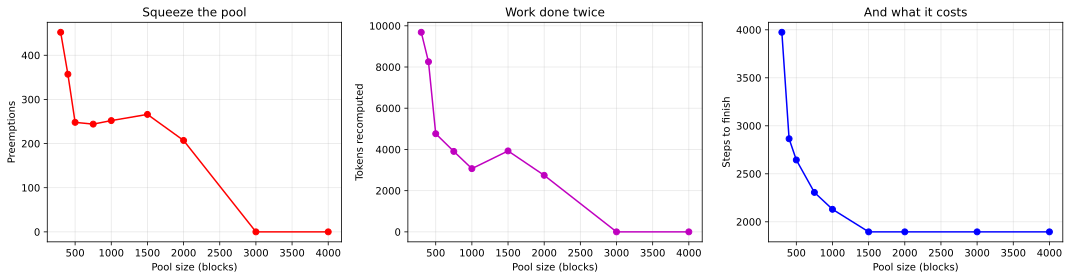

pool   300:   452 preemptions,   9,685 recomputed,   3,974 steps
pool   400:   357 preemptions,   8,254 recomputed,   2,865 steps
pool   500:   248 preemptions,   4,762 recomputed,   2,644 steps
pool   750:   244 preemptions,   3,904 recomputed,   2,306 steps
pool  1000:   252 preemptions,   3,068 recomputed,   2,130 steps
pool  1500:   266 preemptions,   3,928 recomputed,   1,895 steps
pool  2000:   207 preemptions,   2,743 recomputed,   1,895 steps
pool  3000:     0 preemptions,       0 recomputed,   1,895 steps
pool  4000:     0 preemptions,       0 recomputed,   1,895 steps


In [5]:
pools = np.array([300, 400, 500, 750, 1000, 1500, 2000, 3000, 4000])
rows  = [simulate(int(p)) for p in pools]

fig, axs = plt.subplots(1,3, figsize=(15,4))
axs[0].plot(pools, [r['preemptions'] for r in rows], 'ro-')
axs[0].set(xlabel='Pool size (blocks)', ylabel='Preemptions', title='Squeeze the pool')
axs[1].plot(pools, [r['recomputed'] for r in rows], 'mo-')
axs[1].set(xlabel='Pool size (blocks)', ylabel='Tokens recomputed', title='Work done twice')
axs[2].plot(pools, [r['steps'] for r in rows], 'bo-')
axs[2].set(xlabel='Pool size (blocks)', ylabel='Steps to finish', title='And what it costs')
for a in axs: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

for p, r in zip(pools, rows):
  print(f"pool {p:>5}: {r['preemptions']:>5} preemptions, {r['recomputed']:>7,} recomputed, {r['steps']:>7,} steps")

### Read the third plot, not the first

Preemptions rising is not by itself bad news. Preemption is how the
scheduler stays correct under pressure, and a system that never preempts is
one that over-provisioned.

What matters is whether the **steps** curve stays flat as you squeeze. Where
it turns up, you are paying for work you already did, and the machine is
busy without being productive.

That is the measurement stage 10 asks for:

> under overload, does throughput degrade gracefully, or collapse?

A collapsing scheduler looks exactly like a hardware problem to anyone who
is not watching the preemption counter. Which is why stage 16 makes you
export it.

    ./vc guide 10